# Setup

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Load target image

In [395]:
from PIL import Image, ImageDraw

In [5]:
# load image and convert it to grayscale
target_img = Image.open('square_doggo.png').convert('L')
# create a container image for the optimization process
current_img = Image.new('L', target_img.size, color=(255))

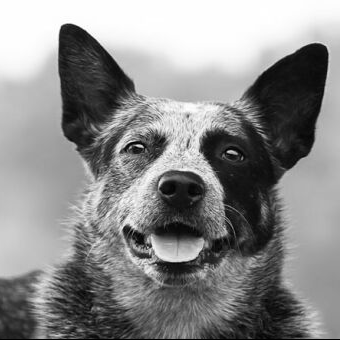

In [6]:
target_img

In [7]:
# define the loss/optimality function
from skimage.metrics import structural_similarity as ssim

def evaluate_similarity(target_img, candidate_img):
    im1 = np.asarray(target_img)
    im2 = np.asarray(candidate_img)
    return ssim(im1, im2)

evaluate_similarity(target_img, current_img)

0.4000118969934553

# Approach 1: Naive strokes

## Trial move definition

In [33]:
def add_line(current_img):
    '''Adds a random stroke in the canvas'''
    # Copy instance of current image and initialize draw module
    candidate_img = current_img.copy()
    draw = ImageDraw.Draw(candidate_img)
    
    # sample two random points (4 coordinates)
    four_coordinates = np.random.choice(np.arange(target_img.size[0]), size=4)
    
    # Draw a line between the points
    x1, y1, x2, y2 = four_coordinates
    
    # Random values for thickness and tone
    width = np.random.choice(np.arange(10, 40))
    value = np.random.choice(np.arange(0, 200, 10))
    
    draw.line([(x1,y1), (x2,y2)], width=width, fill=int(value))
    
    return candidate_img

## Optimization

In [17]:
N_trials = 20000

current_img = Image.new('L', target_img.size, color=(255))
current_similarity = evaluate_similarity(target_img, current_img)
list_similarities = [current_similarity]

for i_step in range(1, N_trials+1):
    # Try adding a random line
    candidate_img = add_line(current_img)
    
    # Calculate similarity
    similarity = evaluate_similarity(target_img, candidate_img)
    
    # If similarity has improved, update candidate
    if similarity > current_similarity:
        current_img = candidate_img
        current_similarity = similarity
        
    list_similarities.append(similarity)
    print(f'Step {i_step} / {N_trials}\t{similarity: .3f}', end='\r')

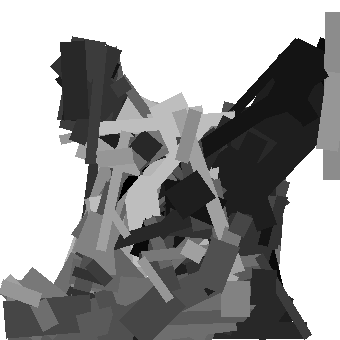

In [18]:
current_img

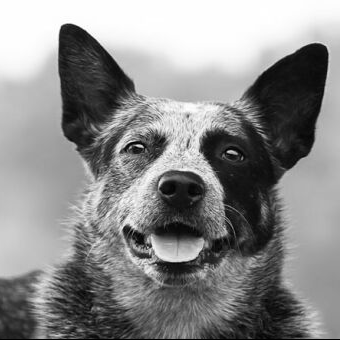

In [ ]:
target_img

Text(0.5, 0, 'Step')

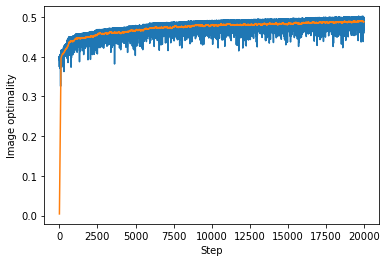

In [37]:
# make a figure to show optimization progress
plt.plot(list_similarities)
mov_avg = np.convolve(list_similarities, v=np.ones(100)/100)
plt.plot(mov_avg[:-100])
plt.ylabel('Image optimality')
plt.xlabel('Step')

# Approach 2: Random walk on a fixed parameter space

## Initialization

I will use triangles instead of strokes, for more interesting results

Each triangle will be define by these parameters:
* 3 points (6 coordinates)
* tone and transparency (2 values)
* Order on the z axis (1 value)
---------------------------------------> A total of 9 parameters

If I use 128 triangles, x9 = 1152 parameters

In [387]:
# initialize randomized starting position in parameter space

# number of triangles
N = 128    
    
# generate the coordinates for the tringles (Nx6); 6 because I need 3 2D points
coordinates = np.random.choice(np.arange(target_img.size[0]), size=(N, 6))

# generate the properties for the triangles
transparency = np.random.choice(np.arange(0, 255, 1), size=(N, 1))
value = np.random.choice(np.arange(0, 255, 1), size=(N, 1))
z_order = np.arange(N).reshape(-1, 1)

mat_parameters = np.concatenate([coordinates, transparency, value, z_order], axis=1)
mat_parameters.shape

(128, 9)

In [388]:
white_canvas = Image.new('L', target_img.size, color=255)

In [389]:
def construct_image(mat_parameters):
    initial_image = Image.new('L', target_img.size, color=255)
    current_img = initial_image

    for i, triangle_para in enumerate(mat_parameters[::-1, :]):
        # draw the predefined geometry
        x1,y1,x2,y2,x3,y3, alpha, tone, index = triangle_para
        new_layer = white_canvas.copy()
        draw = ImageDraw.Draw(new_layer)
        draw.polygon(xy=((x1,y1), (x2,y2), (x3,y3)), fill=int(tone))
        
        # apply the opacity mask
        global_mask = np.ones_like(np.array(new_layer))*255
        mask = np.array(new_layer) < 255
        global_mask[mask == True] = alpha
        global_mask = np.uint8(global_mask)
        mask_img = Image.fromarray(global_mask)

        # Alpha composite these two images together to obtain the desired result.
        stacked_layers = Image.composite(current_img, new_layer, mask=mask_img)
        current_img = stacked_layers
    
    return current_img

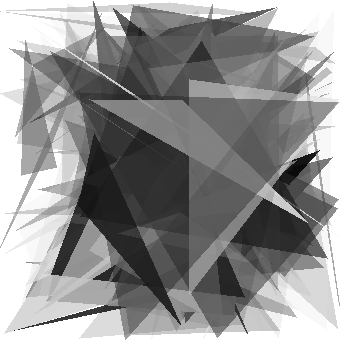

In [390]:
construct_image(mat_parameters)

## Trial move definition

In [391]:
def trial_move(mat_parameters):
    '''Random change to our location on the parameter space'''
    # make a copy to avoid altering the original
    mat_parameters = mat_parameters.copy()
    
    # select a triangle
    rand_i = np.random.choice(np.arange(mat_parameters.shape[0]))
    
    # randomize the triangle parameters
    triangle_para = mat_parameters[rand_i]
    x1,y1,x2,y2,x3,y3, alpha, tone, index = triangle_para
    locations = np.random.choice(np.arange(target_img.size[0]), size=(6))
    values = np.random.choice(np.arange(0, 255, 1), size=(2))
    
    # put the triangle at the top
    triangle_para = np.concatenate([locations, values, [index]])
    top_triangles = mat_parameters[:rand_i]
    bot_triangles = mat_parameters[rand_i+1:]
    mat_parameters = np.vstack((triangle_para.reshape(1,-1), top_triangles, bot_triangles))
    mat_parameters[:, -1] = np.arange(N)
    
    return mat_parameters

## Optimization

In [392]:
N_trials = 50000

current_para = mat_parameters
current_img = construct_image(current_para)
current_similarity = evaluate_similarity(target_img, current_img)

list_similarities = [current_similarity]

for i_step in range(1, N_trials+1):
    # Try adding a random line
    candidate_para = trial_move(current_para)
    candidate_img = construct_image(candidate_para)
    
    # Calculate similarity
    similarity = evaluate_similarity(target_img, candidate_img)
    
    # If similarity has improved, update candidate
    if similarity > current_similarity:
        current_img = candidate_img
        current_para = candidate_para
        current_similarity = similarity
        
    list_similarities.append(similarity)
    print(f'Step {i_step} / {N_trials}\t{similarity: .3f}', end='\r')

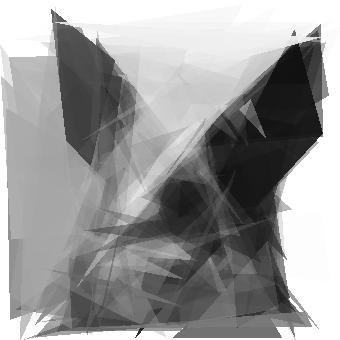

In [393]:
current_img

Text(0.5, 0, 'Step')

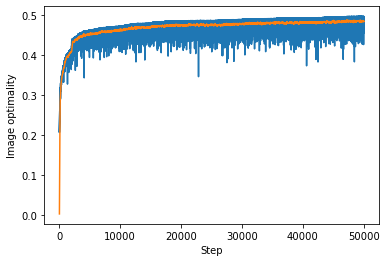

In [394]:
# make a figure to show optimization progress
plt.plot(list_similarities)
mov_avg = np.convolve(list_similarities, v=np.ones(100)/100)
plt.plot(mov_avg[:-100])
plt.ylabel('Image optimality')
plt.xlabel('Step')

# Future plans

* Improved sampling routines (evolution? particle swarm optimization?)
* Improve drawing method (use circles, or other shapes)
* Improved scoring function (RMSD, image features like border detection...)